# Data Analyst - Exploratory Data Analysis

EDA for the RAVDESS speech emotion dataset.

In [30]:
# Import libraries
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 1. Load cleaned metadata

In [31]:
# Find the project folder
PROJECT_ROOT = Path.cwd()

if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

metadata_path = PROJECT_ROOT / "DE_Data_Engineer" / "outputs" / "metadata.csv"

if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

df = pd.read_csv(metadata_path)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (1439, 12)


,file_name,file_path,emotion_code,emotion,actor_id,valid_name,sample_rate,channels,duration,file_size,file_hash,split
0,03-01-01-01-01-01-01.wav,c:\Users\kamal\Documents\de\data\raw\RAVDESS\A...,1,neutral,1,True,16000,1,3.303313,105784,195be393137655ae98afcfa935a88d0c,development
1,03-01-01-01-01-02-01.wav,c:\Users\kamal\Documents\de\data\raw\RAVDESS\A...,1,neutral,1,True,16000,1,3.336688,106852,dfbcfd1f1fce467a3d69c1920d5f1aa7,development
2,03-01-01-01-02-01-01.wav,c:\Users\kamal\Documents\de\data\raw\RAVDESS\A...,1,neutral,1,True,16000,1,3.269938,104716,026f5afdb93115ce784d59fa9f0b9099,development
3,03-01-01-01-02-02-01.wav,c:\Users\kamal\Documents\de\data\raw\RAVDESS\A...,1,neutral,1,True,16000,1,3.169875,101514,e17bd75566571eef27686d1767b786ee,development
4,03-01-02-01-01-01-01.wav,c:\Users\kamal\Documents\de\data\raw\RAVDESS\A...,2,calm,1,True,16000,1,3.536875,113258,7b100b178192455dbed34e855d942090,development


## 2. Dataset overview

In [32]:
# Basic information
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)


Rows: 1439
Columns: 12

Columns:
['file_name', 'file_path', 'emotion_code', 'emotion', 'actor_id', 'valid_name', 'sample_rate', 'channels', 'duration', 'file_size', 'file_hash', 'split']

Missing values:
file_name       0
file_path       0
emotion_code    0
emotion         0
actor_id        0
valid_name      0
sample_rate     0
channels        0
duration        0
file_size       0
file_hash       0
split           0
dtype: int64

Data types:
file_name           str
file_path           str
emotion_code      int64
emotion             str
actor_id          int64
valid_name         bool
sample_rate       int64
channels          int64
duration        float64
file_size         int64
file_hash           str
split               str
dtype: object


In [33]:
# Statistical summary
df.describe()


,emotion_code,actor_id,sample_rate,channels,duration,file_size
count,1439.000000,1439.000000,1439.0,1439.0,1439.000000,1439.000000
mean,4.734538,12.503822,16000.0,1.0,3.700892,118506.537874
std,2.175632,6.925479,0.0,0.0,0.336701,10774.437828
min,1.000000,1.000000,16000.0,1.0,2.936313,94040.000000
25%,3.000000,6.500000,16000.0,1.0,3.470188,111124.000000
50%,5.000000,13.000000,16000.0,1.0,3.670375,117530.000000
75%,7.000000,18.500000,16000.0,1.0,3.870563,123936.000000
max,8.000000,24.000000,16000.0,1.0,5.271937,168780.000000


## 3. Emotion distribution

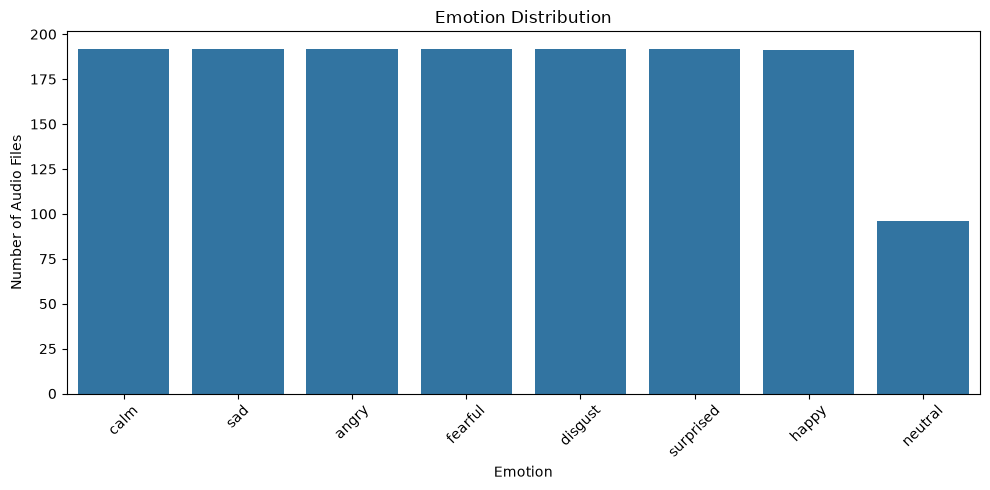

In [34]:
# Count of recordings for each emotion
emotion_counts = df["emotion"].value_counts()

plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x="emotion",
    order=emotion_counts.index
)

plt.title("Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Audio Files")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [35]:
# Emotion percentages
emotion_percent = df["emotion"].value_counts(normalize=True) * 100

emotion_summary = pd.DataFrame({
    "count": emotion_counts,
    "percentage": emotion_percent.round(2)
})

emotion_summary


,count,percentage
emotion,,
calm,192,13.34
sad,192,13.34
angry,192,13.34
fearful,192,13.34
disgust,192,13.34
surprised,192,13.34
happy,191,13.27
neutral,96,6.67


## 4. Actor distribution

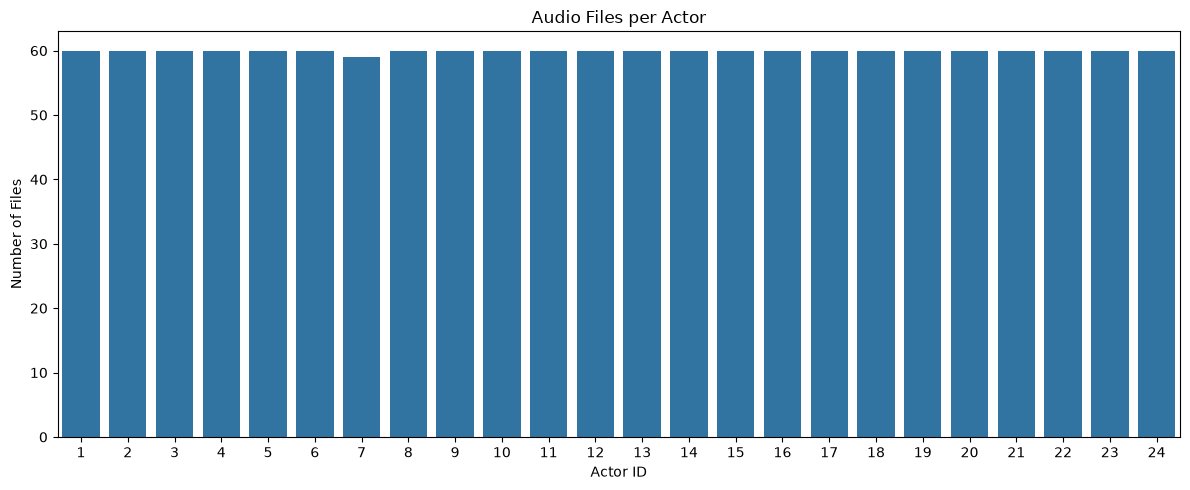

In [36]:
# Number of recordings per actor
actor_counts = df["actor_id"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
sns.barplot(
    x=actor_counts.index,
    y=actor_counts.values
)

plt.title("Audio Files per Actor")
plt.xlabel("Actor ID")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()


## 5. Audio duration distribution

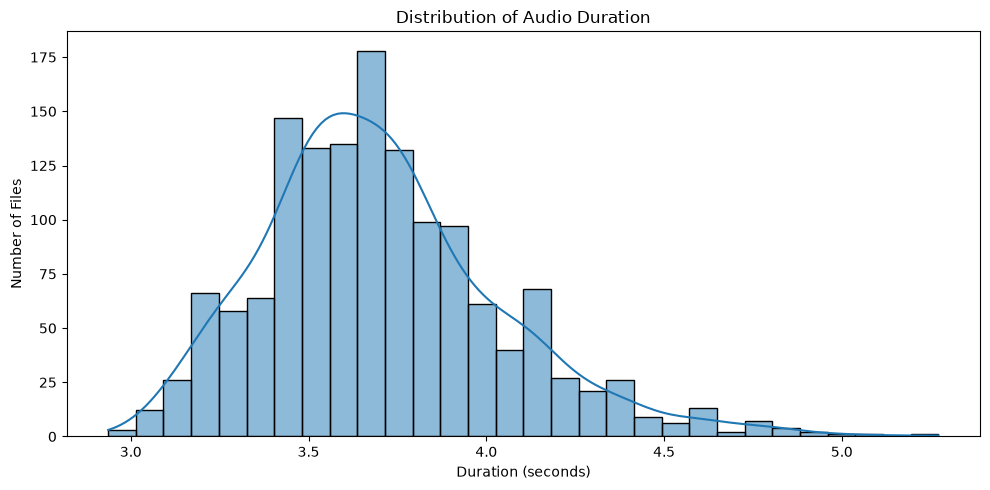

In [37]:
# Overall duration distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["duration"],
    bins=30,
    kde=True
)

plt.title("Distribution of Audio Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()


In [38]:
# Duration statistics
print(df["duration"].describe())

print("\nMean:", round(df["duration"].mean(), 3))
print("Median:", round(df["duration"].median(), 3))
print("Minimum:", round(df["duration"].min(), 3))
print("Maximum:", round(df["duration"].max(), 3))


count    1439.000000
mean        3.700892
std         0.336701
min         2.936313
25%         3.470188
50%         3.670375
75%         3.870563
max         5.271937
Name: duration, dtype: float64

Mean: 3.701
Median: 3.67
Minimum: 2.936
Maximum: 5.272


## 6. Duration by emotion

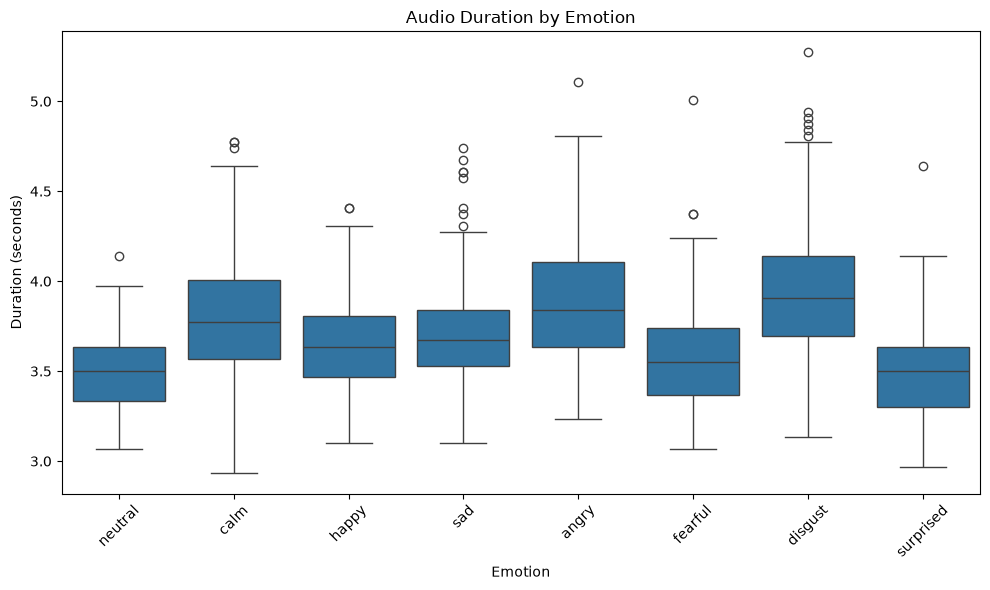

In [39]:
# Compare duration across emotions
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="emotion",
    y="duration"
)

plt.title("Audio Duration by Emotion")
plt.xlabel("Emotion")
plt.ylabel("Duration (seconds)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [40]:
# Duration statistics by emotion
duration_by_emotion = (
    df.groupby("emotion")["duration"]
      .agg(["count", "mean", "median", "std", "min", "max"])
      .round(3)
)

duration_by_emotion


,count,mean,median,std,min,max
emotion,,,,,,
angry,192,3.871,3.837,0.320,3.237,5.105
calm,192,3.796,3.770,0.334,2.936,4.771
disgust,192,3.942,3.904,0.375,3.136,5.272
fearful,192,3.574,3.554,0.292,3.070,5.005
happy,191,3.639,3.637,0.257,3.103,4.404
neutral,96,3.503,3.504,0.212,3.070,4.138
sad,192,3.695,3.670,0.294,3.103,4.738
surprised,192,3.488,3.504,0.239,2.970,4.638


## 7. Distribution and skewness

In [41]:
# Check skewness of numerical features
numeric_columns = [
    "duration",
    "file_size",
    "sample_rate",
    "channels"
]

skewness = df[numeric_columns].skew().sort_values(ascending=False)

print("Skewness:")
print(skewness)


Skewness:
file_size      0.795235
duration       0.795235
sample_rate    0.000000
channels       0.000000
dtype: float64


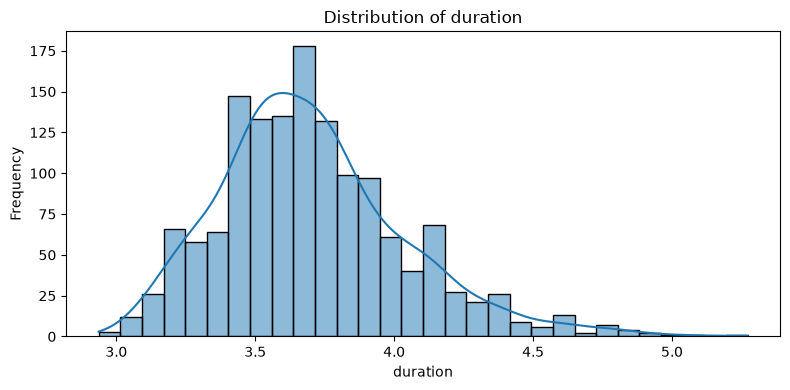

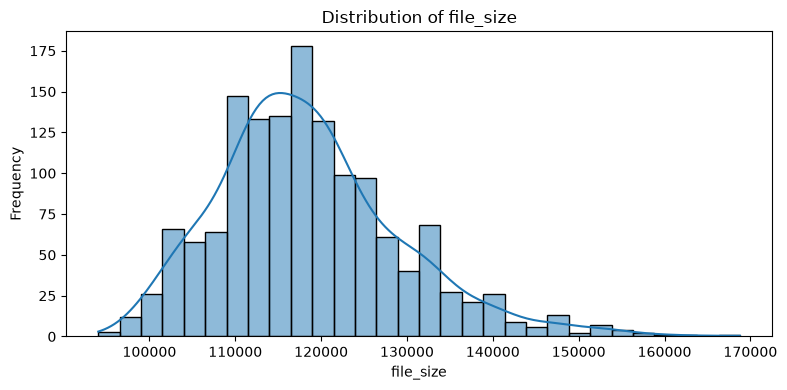

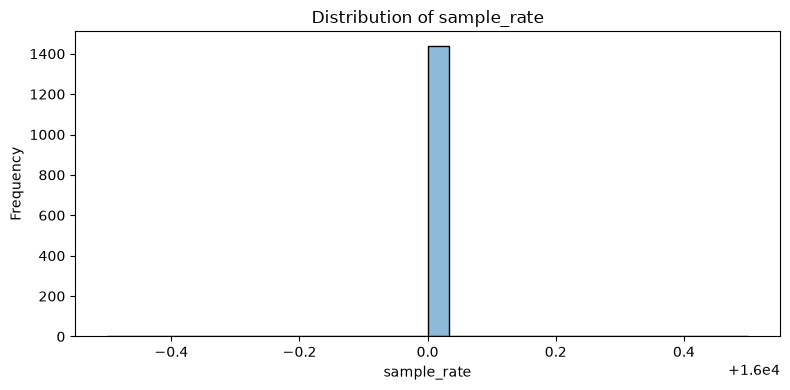

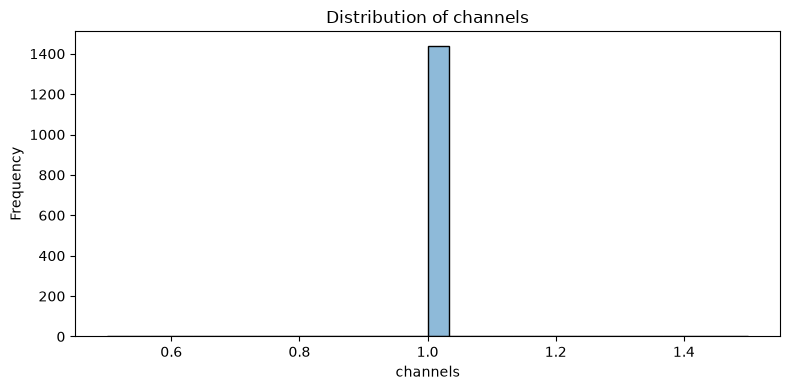

In [42]:
# Plot numerical distributions
for column in numeric_columns:
    plt.figure(figsize=(8, 4))

    sns.histplot(
        df[column],
        kde=True,
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()


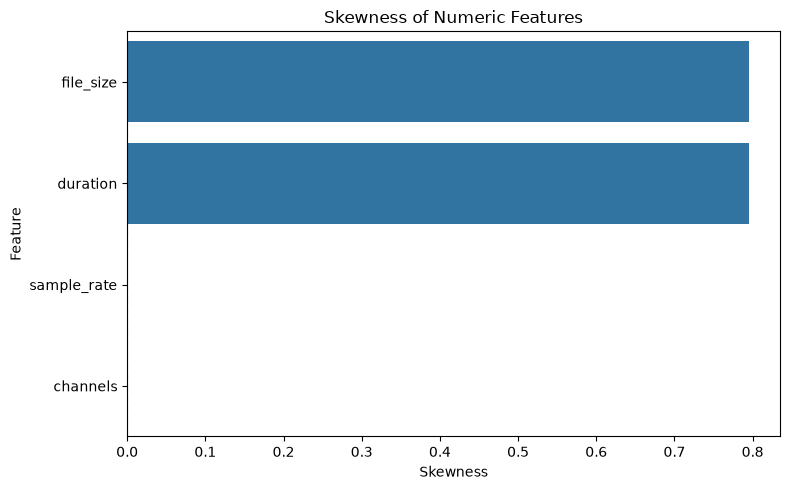

In [43]:
# Plot skewness
plt.figure(figsize=(8, 5))

sns.barplot(
    x=skewness.values,
    y=skewness.index
)

plt.axvline(0, linestyle="--")

plt.title("Skewness of Numeric Features")
plt.xlabel("Skewness")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 8. Outlier and anomaly detection

In [44]:
# Find outliers using the IQR method
def find_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)

    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = data[
        (data[column] < lower) |
        (data[column] > upper)
    ]

    return outliers, lower, upper


In [45]:
# Check duration outliers
duration_outliers, lower, upper = find_outliers(df, "duration")

print("Lower limit:", round(lower, 3))
print("Upper limit:", round(upper, 3))
print("Number of duration outliers:", len(duration_outliers))

duration_outliers[
    ["file_name", "actor_id", "emotion", "duration"]
].head(10)


Lower limit: 2.87
Upper limit: 4.471
Number of duration outliers: 40


,file_name,actor_id,emotion,duration
40,03-01-06-02-01-01-01.wav,1,fearful,5.005000
155,03-01-05-02-02-02-03.wav,3,angry,4.504500
248,03-01-02-02-01-01-05.wav,5,calm,4.738062
249,03-01-02-02-01-02-05.wav,5,calm,4.504500
250,03-01-02-02-02-01-05.wav,5,calm,4.771438
291,03-01-07-02-02-02-05.wav,5,disgust,4.537875
308,03-01-02-02-01-01-06.wav,6,calm,4.504500
309,03-01-02-02-01-02-06.wav,6,calm,4.638000
311,03-01-02-02-02-02-06.wav,6,calm,4.771438
326,03-01-04-02-02-01-06.wav,6,sad,4.604625


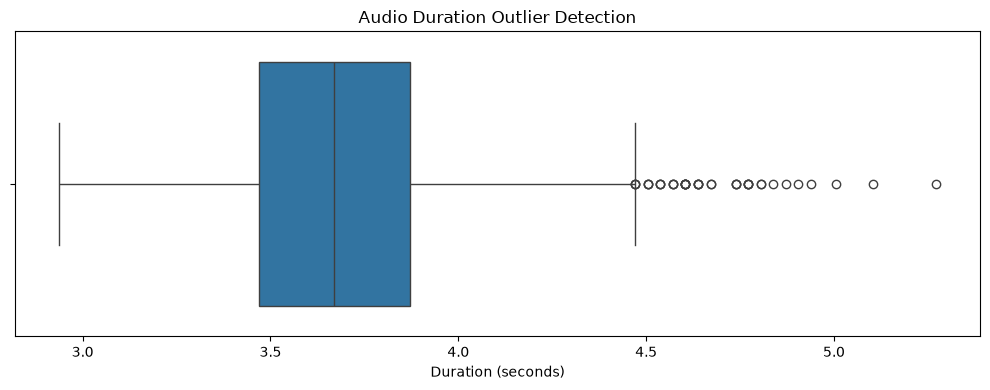

In [46]:
# Visualize duration outliers
plt.figure(figsize=(10, 4))

sns.boxplot(x=df["duration"])

plt.title("Audio Duration Outlier Detection")
plt.xlabel("Duration (seconds)")
plt.tight_layout()
plt.show()


## 9. File size analysis

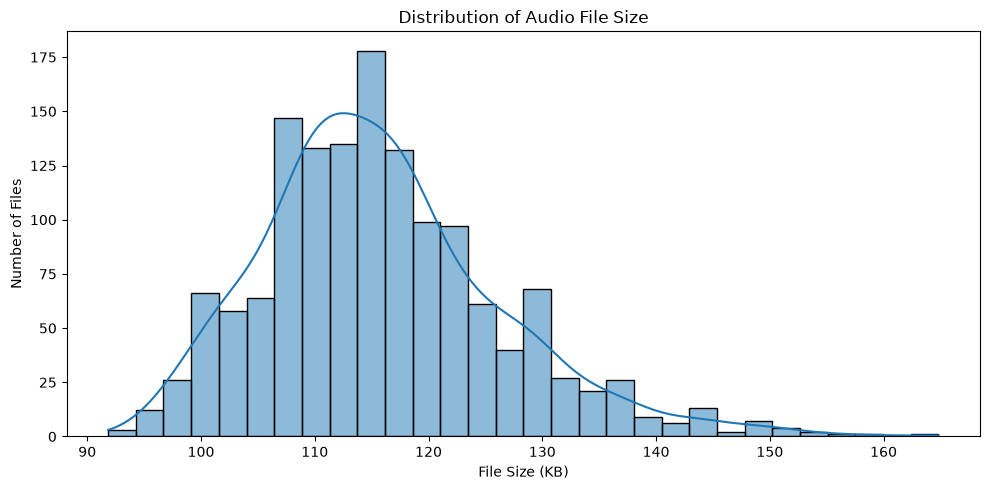

In [47]:
# File size distribution
plt.figure(figsize=(10, 5))

sns.histplot(
    df["file_size"] / 1024,
    bins=30,
    kde=True
)

plt.title("Distribution of Audio File Size")
plt.xlabel("File Size (KB)")
plt.ylabel("Number of Files")
plt.tight_layout()
plt.show()


## 10. Correlation analysis

In [48]:
# Correlation between useful numerical variables
correlation = df[[
    "duration",
    "file_size"
]].corr()

print(correlation)


           duration  file_size
duration        1.0        1.0
file_size       1.0        1.0


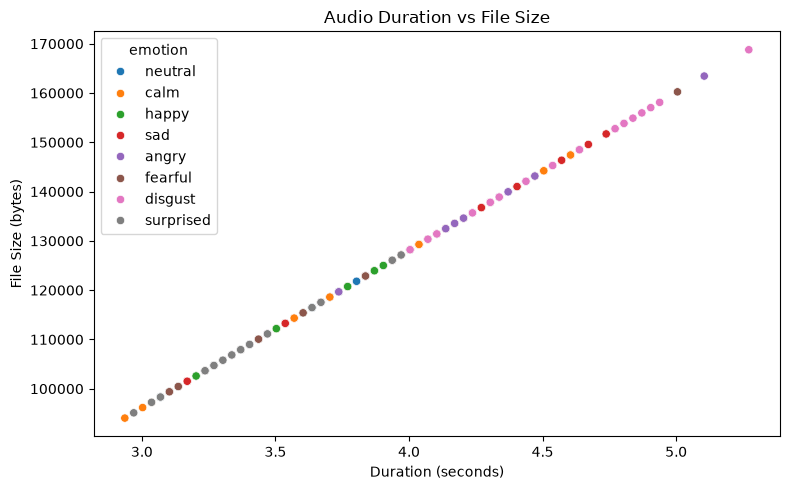

In [49]:
# Duration versus file size
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="duration",
    y="file_size",
    hue="emotion"
)

plt.title("Audio Duration vs File Size")
plt.xlabel("Duration (seconds)")
plt.ylabel("File Size (bytes)")
plt.tight_layout()
plt.show()


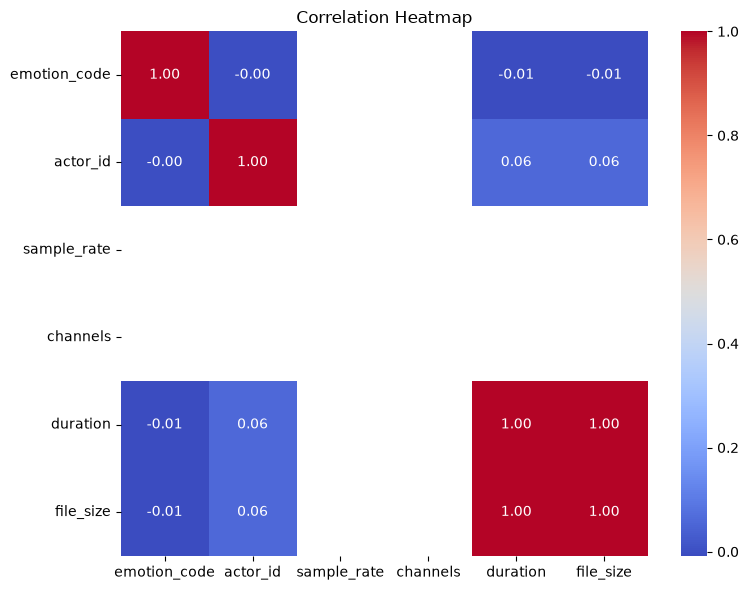

In [50]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=np.number)
correlation_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


## 11. Emotion-wise statistical analysis

In [51]:
# Compare numerical features across emotions
emotion_stats = (
    df.groupby("emotion")
      .agg({
          "duration": ["mean", "median", "std"],
          "file_size": ["mean", "median"]
      })
      .round(3)
)

emotion_stats


duration                 file_size          
              mean median    std        mean    median
emotion                                               
angry        3.871  3.837  0.320  123963.573  122868.0
calm         3.796  3.770  0.334  121544.365  120732.0
disgust      3.942  3.904  0.375  126215.823  125004.0
fearful      3.574  3.554  0.292  114454.062  113792.0
happy        3.639  3.637  0.257  116539.822  116462.0
neutral      3.503  3.504  0.212  112179.583  112190.0
sad          3.695  3.670  0.294  118302.344  117530.0
surprised    3.488  3.504  0.239  111679.010  112190.0

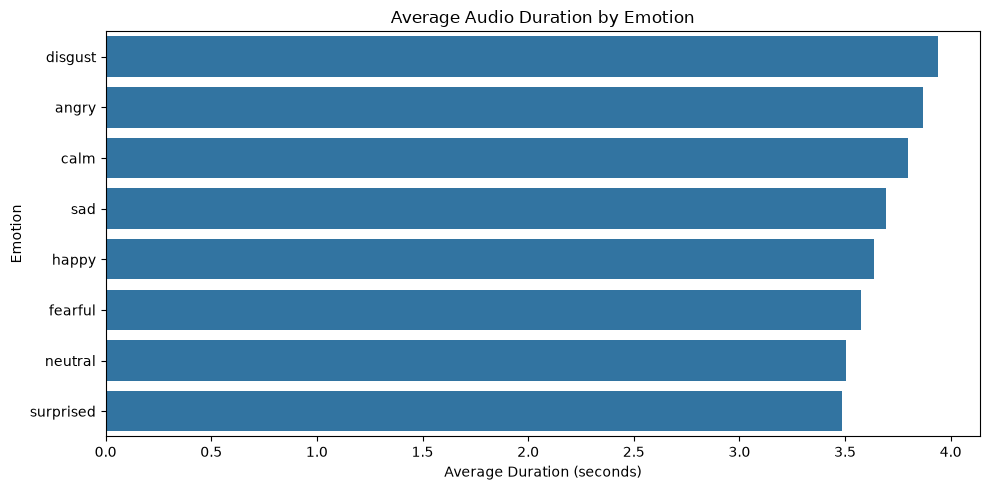

In [52]:
# Average duration by emotion
mean_duration = (
    df.groupby("emotion")["duration"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=mean_duration.values,
    y=mean_duration.index
)

plt.title("Average Audio Duration by Emotion")
plt.xlabel("Average Duration (seconds)")
plt.ylabel("Emotion")
plt.tight_layout()
plt.show()


## 12. Actor vs emotion analysis

In [53]:
# Count recordings for every actor-emotion combination
actor_emotion = pd.crosstab(
    df["actor_id"],
    df["emotion"]
)

actor_emotion


emotion,angry,calm,disgust,fearful,happy,neutral,sad,surprised
actor_id,,,,,,,,
1,8,8,8,8,8,4,8,8
2,8,8,8,8,8,4,8,8
3,8,8,8,8,8,4,8,8
4,8,8,8,8,8,4,8,8
5,8,8,8,8,8,4,8,8
6,8,8,8,8,8,4,8,8
7,8,8,8,8,7,4,8,8
8,8,8,8,8,8,4,8,8
9,8,8,8,8,8,4,8,8


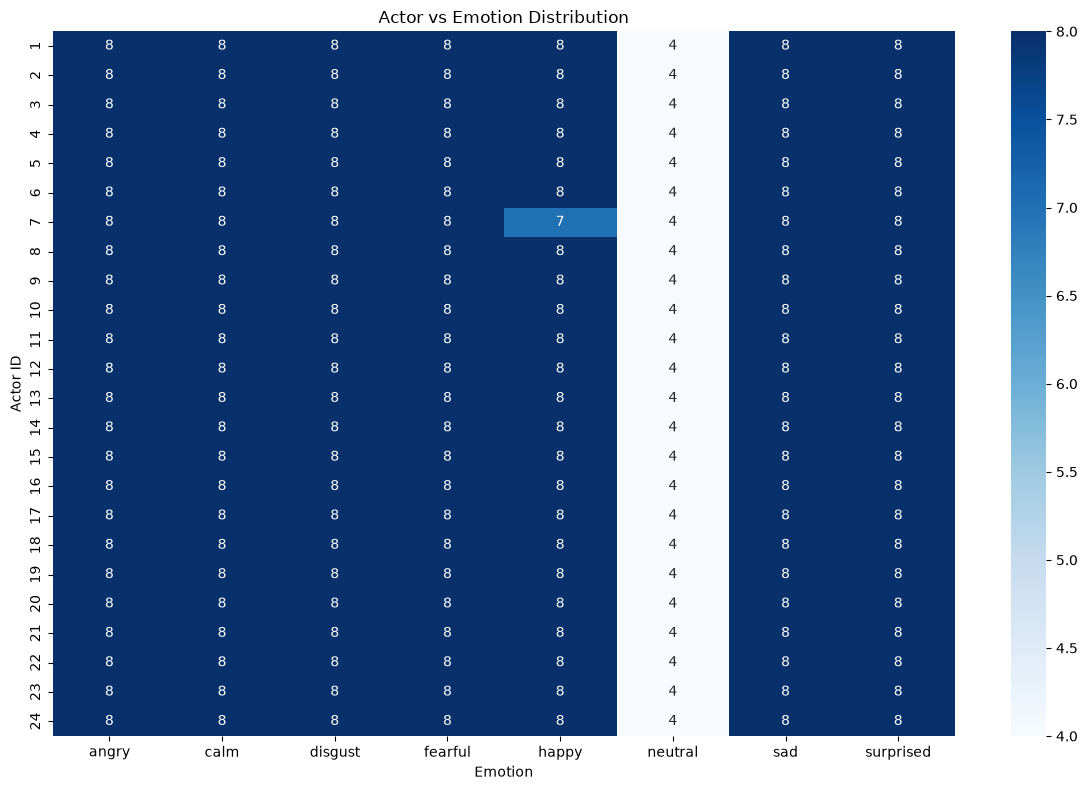

In [54]:
# Visualize actor-emotion distribution
plt.figure(figsize=(12, 8))

sns.heatmap(
    actor_emotion,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Actor vs Emotion Distribution")
plt.xlabel("Emotion")
plt.ylabel("Actor ID")
plt.tight_layout()
plt.show()


## 13. Find the strongest numerical relationships

In [55]:
# Rank numerical feature correlations
corr = numeric_df.corr()

pairs = []

for i in range(len(corr.columns)):
    for j in range(i + 1, len(corr.columns)):
        feature_1 = corr.columns[i]
        feature_2 = corr.columns[j]
        value = corr.iloc[i, j]

        pairs.append({
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": value
        })

correlation_pairs = pd.DataFrame(pairs)

correlation_pairs["absolute_correlation"] = (
    correlation_pairs["correlation"].abs()
)

correlation_pairs = correlation_pairs.sort_values(
    "absolute_correlation",
    ascending=False
)

correlation_pairs


,feature_1,feature_2,correlation,absolute_correlation
14,duration,file_size,1.00000,1.00000
8,actor_id,file_size,0.05815,0.05815
7,actor_id,duration,0.05815,0.05815
3,emotion_code,duration,-0.00831,0.00831
4,emotion_code,file_size,-0.00831,0.00831
0,emotion_code,actor_id,-0.00044,0.00044
1,emotion_code,sample_rate,NaN,NaN
2,emotion_code,channels,NaN,NaN
5,actor_id,sample_rate,NaN,NaN
6,actor_id,channels,NaN,NaN


## 14. Top 3 actionable data insights

In [56]:
# Generate insights from the analysis
largest_emotion = emotion_counts.idxmax()
smallest_emotion = emotion_counts.idxmin()

largest_emotion_count = emotion_counts.max()
smallest_emotion_count = emotion_counts.min()

duration_skew = df["duration"].skew()

strongest_pair = correlation_pairs.iloc[0]

print("TOP 3 ACTIONABLE DATA INSIGHTS")
print("-" * 40)

print(
    f"1. Emotion distribution: {largest_emotion} has the most recordings "
    f"({largest_emotion_count}), while {smallest_emotion} has the fewest "
    f"({smallest_emotion_count})."
)

print(
    f"2. Duration distribution: audio duration has a skewness of "
    f"{duration_skew:.3f}. This should be considered when interpreting "
    f"duration-based analysis."
)

print(
    f"3. Strongest numerical relationship: {strongest_pair['feature_1']} "
    f"and {strongest_pair['feature_2']} have a correlation of "
    f"{strongest_pair['correlation']:.3f}."
)


TOP 3 ACTIONABLE DATA INSIGHTS
----------------------------------------
1. Emotion distribution: calm has the most recordings (192), while neutral has the fewest (96).
2. Duration distribution: audio duration has a skewness of 0.795. This should be considered when interpreting duration-based analysis.
3. Strongest numerical relationship: duration and file_size have a correlation of 1.000.


## 15. Save DA outputs

In [58]:
# Save statistical results
OUTPUT_PATH = PROJECT_ROOT / "DA_Data_Analyst" / "outputs"

if not OUTPUT_PATH.exists():
    raise FileNotFoundError(
        f"DA output folder not found: {OUTPUT_PATH}"
    )

emotion_summary.to_csv(
    OUTPUT_PATH / "emotion_distribution.csv"
)

duration_by_emotion.to_csv(
    OUTPUT_PATH / "duration_statistics.csv"
)

correlation_pairs.to_csv(
    OUTPUT_PATH / "correlation_analysis.csv",
    index=False
)

print("DA analysis outputs saved.")


DA analysis outputs saved.
